# Dental Image Classifier — Google Colab

Notebook para treinamento do classificador de vistas intraorais odontológicas usando PyTorch e ResNet-18 com transfer learning.

**Vistas classificadas:** frontal, inferior, superior, lateral direita, lateral esquerda

> **Recomendado:** habilite GPU em *Ambiente de execução → Alterar tipo de ambiente de execução → GPU T4*.

## 1. Setup — Clone e dependências

In [1]:
!git clone -b feature/pytorch-train-test-split https://github.com/taynaramos/dental-image-classifier.git /content/dental-image-classifier
!pip install gdown -q

Cloning into '/content/dental-image-classifier'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (80/80), done.
Receiving objects: 100% (124/124), 56.69 KiB | 983.00 KiB/s, done.
Resolving deltas: 100% (37/37), done.
remote: Total 124 (delta 37), reused 107 (delta 28), pack-reused 0 (from 0)


In [2]:
import sys
sys.path.insert(0, '/content/dental-image-classifier')

import os
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 2. Download do Dataset

O dataset é baixado do Google Drive uma vez por sessão do Colab.
Se a sessão for reiniciada, a célula abaixo baixa novamente.

In [3]:
from src.data.dataset_download import preparar_dataset

FILE_ID = '11XFNZe6KpP2Jkhb6SkAOuYkl3rfEoOX9'

dataset_root = preparar_dataset(
    file_id=FILE_ID,
    zip_destino='/content/dataset.zip',
    extract_dir='/content/dataset',
)

Downloading...
From (original): https://drive.google.com/uc?id=11XFNZe6KpP2Jkhb6SkAOuYkl3rfEoOX9
From (redirected): https://drive.google.com/uc?id=11XFNZe6KpP2Jkhb6SkAOuYkl3rfEoOX9&confirm=t&uuid=7b4b9a8a-cec0-451c-bcaa-0e81bb78fd7e
To: /content/dataset.zip
100%|██████████| 1.22G/1.22G [00:15<00:00, 77.0MB/s]


Download concluído: /content/dataset.zip (1166.5 MB)
Extração concluída em: /content/dataset
Total de pastas (casos): 300
Pastas válidas: 300
Pastas com problema: 0
Dataset pronto em: /content/dataset (300 casos válidos)


## 3. Dataset PyTorch

A divisão treino/validação é feita **por paciente** (não por imagem),
evitando que fotos do mesmo paciente apareçam em treino e validação simultaneamente.

In [7]:
STEM_TO_IDX = {
    'intraoral-frontal': 0,
    'intraoral-inferior': 1,
    'intraoral-superior': 2,
    'intraoral-lateral-direita': 3,
    'intraoral-lateral-esquerda': 4,
}
CLASSES = ['frontal', 'inferior', 'superior', 'lateral_direita', 'lateral_esquerda']


class DentalDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples  # list of (Path, int)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


def build_splits(dataset_root, val_ratio=0.15, test_ratio=0.15, seed=42):
    root = Path(dataset_root)
    patient_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    random.seed(seed)
    random.shuffle(patient_dirs)

    n_val = int(len(patient_dirs) * val_ratio)
    n_test = int(len(patient_dirs) * test_ratio)
    val_patients = patient_dirs[:n_val]
    test_patients = patient_dirs[n_val:n_val + n_test]
    train_patients = patient_dirs[n_val + n_test:]

    def collect(patients):
        samples = []
        for p in patients:
            for img_file in p.glob('*.jpeg'):
                if img_file.stem in STEM_TO_IDX:
                    samples.append((img_file, STEM_TO_IDX[img_file.stem]))
        return samples

    return collect(train_patients), collect(val_patients), collect(test_patients)

train_samples, val_samples, test_samples = build_splits(dataset_root)
print(f'Treino: {len(train_samples)} | Validacao: {len(val_samples)} | Teste: {len(test_samples)}')

Treino: 1050 | Validacao: 225 | Teste: 225


## 4. Transforms e DataLoaders

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    # T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

BATCH_SIZE = 32

train_loader = DataLoader(
    DentalDataset(train_samples, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    DentalDataset(val_samples, val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
)

test_loader = DataLoader(
    DentalDataset(test_samples, val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
)
print(f'Batches teste: {len(test_loader)}')
print(f'Batches treino: {len(train_loader)} | Batches validacao: {len(val_loader)}')

Batches teste: 8
Batches treino: 33 | Batches validacao: 8


## 5. Modelo — ResNet-18 com Transfer Learning

Substituímos apenas a última camada fully-connected para adaptar ao problema de 5 classes.

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totais: {total_params:,}')
print(f'Ultima camada: {model.fc}')

Parametros totais: 11,179,077
Ultima camada: Linear(in_features=512, out_features=5, bias=True)


## 6. Treinamento

**Fase 1 (5 épocas):** backbone congelado, treina só a última camada (FC).
**Fase 2 (15 épocas):** fine-tune completo com learning rate menor.

O melhor modelo (maior acurácia de validação) é salvo automaticamente em `best_model.pth`.

In [11]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (outputs.detach().argmax(1) == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * len(labels)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += len(labels)
    return total_loss / total, correct / total

In [12]:
criterion = nn.CrossEntropyLoss()

# Fase 1: backbone congelado
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

print('=== Fase 1: backbone congelado ===')
for epoch in range(1, 6):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(va_loss)
    print(f'Epoca {epoch:02d} | treino loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.3f}')

# Fase 2: fine-tune completo
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_acc = 0.0
print('\n=== Fase 2: fine-tune completo ===')
for epoch in range(1, 16):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(va_loss)
    saved = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), 'best_model.pth')
        saved = ' <- melhor salvo'
    print(f'Epoca {epoch:02d} | treino loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.3f}{saved}')

print(f'\nMelhor acuracia de validacao: {best_val_acc:.3f}')

=== Fase 1: backbone congelado ===
Epoca 01 | treino loss 1.1726 acc 0.567 | val loss 0.6944 acc 0.782
Epoca 02 | treino loss 0.6690 acc 0.762 | val loss 0.4809 acc 0.858
Epoca 03 | treino loss 0.5503 acc 0.791 | val loss 0.4118 acc 0.862
Epoca 04 | treino loss 0.4667 acc 0.818 | val loss 0.3875 acc 0.853
Epoca 05 | treino loss 0.4102 acc 0.843 | val loss 0.3587 acc 0.858

=== Fase 2: fine-tune completo ===
Epoca 01 | treino loss 0.1511 acc 0.950 | val loss 0.0094 acc 1.000 <- melhor salvo
Epoca 02 | treino loss 0.0246 acc 0.993 | val loss 0.0266 acc 0.991
Epoca 03 | treino loss 0.0207 acc 0.993 | val loss 0.0216 acc 0.987
Epoca 04 | treino loss 0.0193 acc 0.995 | val loss 0.0024 acc 1.000
Epoca 05 | treino loss 0.0147 acc 0.997 | val loss 0.0080 acc 1.000
Epoca 06 | treino loss 0.0060 acc 0.999 | val loss 0.0016 acc 1.000
Epoca 07 | treino loss 0.0025 acc 1.000 | val loss 0.0012 acc 1.000
Epoca 08 | treino loss 0.0019 acc 1.000 | val loss 0.0015 acc 1.000
Epoca 09 | treino loss 0.0012

In [13]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))

train_loss, train_acc = eval_epoch(model, train_loader, criterion)
test_loss, test_acc = eval_epoch(model, test_loader, criterion)

print(f"Erro de treino: {train_loss:.4f} (acc {train_acc:.3f})")
print(f"Erro de teste : {test_loss:.4f} (acc {test_acc:.3f})")

Erro de treino: 0.0179 (acc 0.995)
Erro de teste : 0.0071 (acc 0.996)


## 7. Avaliação

Relatório completo por classe e matriz de confusão.

                  precision    recall  f1-score   support

         frontal       1.00      1.00      1.00        45
        inferior       1.00      1.00      1.00        45
        superior       1.00      1.00      1.00        45
 lateral_direita       0.98      1.00      0.99        45
lateral_esquerda       1.00      0.98      0.99        45

        accuracy                           1.00       225
       macro avg       1.00      1.00      1.00       225
    weighted avg       1.00      1.00      1.00       225



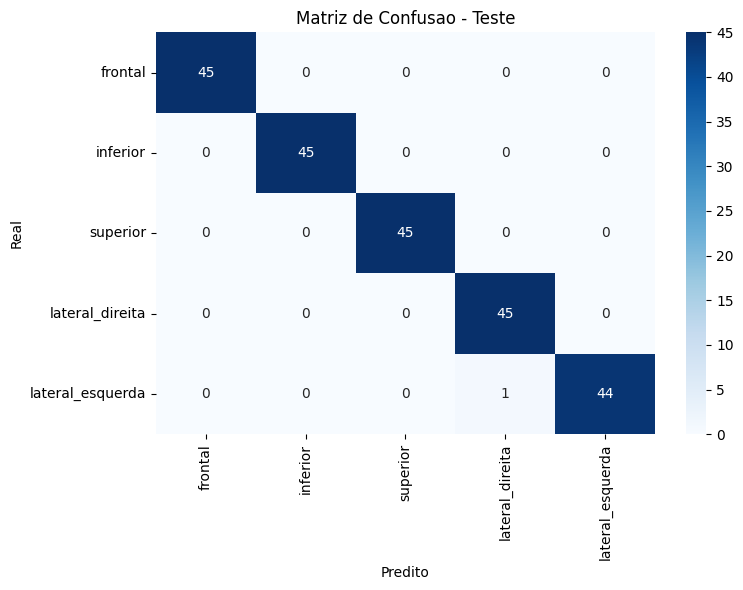

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title('Matriz de Confusao - Teste')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [15]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('best_model.pth', '/content/drive/MyDrive/best_model.pth')

Mounted at /content/drive


'/content/drive/MyDrive/best_model.pth'